# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FALAKNAZMALICK/MY-ML-Internship/blob/main/work/notebooks/w07_action_playbook.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

To transform raw decision-support scores into actionable human workflows, every URL in our output queue is mapped to a specific **Action Archetype** paired with an operational **Reason Code**:

| Action Label | Reason Code | Trigger Conditions | Editorial Guidance |
| :--- | :--- | :--- | :--- |
| `REFRESH_CONTENT` | `ZERO_CLICK_HIGH_IMPRESSIONS` | `gsc_impressions > 100` AND `gsc_clicks == 0` | High impressions paired with zero engagement indicate a severe search intent mismatch or meta-title decay. Update snippet titles, headings, and intent alignment. |
| `REFRESH_CONTENT` | `LOW_CTR_RISK` | `gsc_impressions > 0` AND `ctr < 0.02` | Page ranks within search results but suffers from below-average click-through rates. Perform meta-description optimization and SERP feature audit. |
| `MONITOR_PERFORMANCE` | `LOW_VISIBILITY_DECAY` | `gsc_impressions <= 100` AND `gsc_avg_position > 50` | Low historical impression volume with deep positional drop. Re-evaluate keyword targeting before allocating editorial refresh resources. |

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

#### Intended Use:
*   **Decision-Support Tool:** Designed for content leads and SEO managers to prioritize weekly editorial refresh queues.
*   **Resource Allocation:** Directs limited writer/editor bandwidth toward high-visibility, low-efficiency assets (quick wins).

#### Known Boundaries & Limitations:
*   **Non-Production Scope:** The system outputs directional heuristic priorities, not automated content rewrites.
*   **SERP Layout Blind Spots:** The model cannot directly detect SERP feature changes (e.g., massive Google AI Overviews or knowledge panels cannibalizing organic clicks).
*   **Niche & Seasonal Volatility:** Low-volume B2B topics or seasonal articles may trigger decay flags outside their peak cycles despite being content-accurate.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

#### Human Pre-Action Checklist:
1.  **SERP Intent Verification:** Confirm if Google's search result layout for the primary keyword introduced new AI Overviews or featured snippets that hoard user clicks.
2.  **Evergreen Accuracy Audit:** Ensure the page isn't an unchanged reference article that remains accurate despite lack of recent updates.
3.  **Technical & Tracking Check:** Verify that Google Search Console tags/analytics scripts were active during the snapshot window.

#### Strict No-Go List (What Must NEVER Be Automated):
*   **Automated Content Rewrites:** Never allow AI agents to auto-generate and publish page copy directly to production without human editorial oversight.
*   **Bulk Page Deletions or Redirects:** Never automate 301 redirects or page prunings based solely on baseline decay scores.
*   **Compliance & Legal Assets:** Never automate updates on legal, financial (YMYL), or privacy-policy documentation.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

#### Stale Recommendation Triggers:
*   **Data Drift Signal:** A systemic shift in click distributions (e.g., across-the-board CTR drop due to major search engine core algorithm updates).
*   **Concept Drift Signal:** A marked decline in model Precision/Recall on validation sets across consecutive monthly data snapshots.
*   **Cadence Trigger:** Recommendations should be refreshed monthly. Models must be re-evaluated quarterly using updated client traffic partitions.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

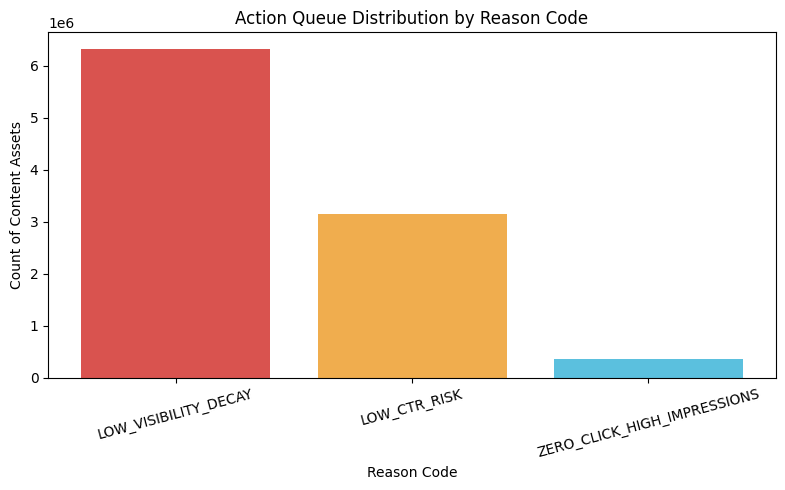

Successfully exported action queue (9841378 rows) to work/outputs/action_playbook_queue.csv
Successfully saved metrics receipt to work/outputs/playbook_metrics.json
Successfully saved figure to work/figures/reason_code_distribution.png


In [2]:
import os
import json
import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
from google.colab import userdata

hf_token = userdata.get('HF_TOKEN')
con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")
con.execute(f"CREATE OR REPLACE SECRET hf_token (TYPE huggingface, TOKEN '{hf_token}');")

BASE_URL = "hf://datasets/FlyRank/internship-warehouse"

query = f"""
SELECT
    content_hash_id,
    client_hash_id,
    gsc_impressions,
    gsc_clicks,
    gsc_avg_position,
    CASE
        WHEN gsc_impressions > 0 THEN CAST(gsc_clicks AS FLOAT) / gsc_impressions
        ELSE 0.0
    END as ctr
FROM read_parquet('{BASE_URL}/fact_content_daily_performance/month=2026-03/*.parquet')
"""
df = con.execute(query).df()

for col in ['gsc_impressions', 'gsc_clicks', 'gsc_avg_position', 'ctr']:
    df[col] = df[col].fillna(0.0)

max_pos = df['gsc_avg_position'].max() if df['gsc_avg_position'].max() > 0 else 1
df['baseline_score'] = ((df['gsc_avg_position'] / max_pos) * 50 + (1.0 - df['ctr']) * 50).clip(0, 100)

conditions = [
    (df['gsc_impressions'] > 100) & (df['gsc_clicks'] == 0),
    (df['gsc_impressions'] > 0) & (df['ctr'] < 0.02)
]
choices_action = ['REFRESH_CONTENT', 'REFRESH_CONTENT']
choices_reason = ['ZERO_CLICK_HIGH_IMPRESSIONS', 'LOW_CTR_RISK']

df['action_label'] = np.select(conditions, choices_action, default='MONITOR_PERFORMANCE')
df['reason_code'] = np.select(conditions, choices_reason, default='LOW_VISIBILITY_DECAY')

queue = df[['content_hash_id', 'client_hash_id', 'baseline_score', 'action_label', 'reason_code']].sort_values(
    by='baseline_score', ascending=False
)

os.makedirs('../outputs', exist_ok=True)
os.makedirs('../figures', exist_ok=True)

queue.to_csv('../outputs/action_playbook_queue.csv', index=False)

metrics_receipt = {
    "total_evaluated_urls": int(len(df)),
    "prioritized_refreshes": int((df['action_label'] == 'REFRESH_CONTENT').sum()),
    "zero_click_high_impressions_count": int((df['reason_code'] == 'ZERO_CLICK_HIGH_IMPRESSIONS').sum()),
    "low_ctr_risk_count": int((df['reason_code'] == 'LOW_CTR_RISK').sum())
}
with open('../outputs/playbook_metrics.json', 'w') as f:
    json.dump(metrics_receipt, f, indent=4)

plt.figure(figsize=(8, 5))
reason_counts = queue['reason_code'].value_counts()
plt.bar(reason_counts.index, reason_counts.values, color=['#d9534f', '#f0ad4e', '#5bc0de'])
plt.title('Action Queue Distribution by Reason Code')
plt.xlabel('Reason Code')
plt.ylabel('Count of Content Assets')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../figures/reason_code_distribution.png', dpi=300)
plt.show()

print(f"Successfully exported action queue ({len(queue)} rows) to work/outputs/action_playbook_queue.csv")
print("Successfully saved metrics receipt to work/outputs/playbook_metrics.json")
print("Successfully saved figure to work/figures/reason_code_distribution.png")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.